# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = '/content/drive/MyDrive/Submission/hasil_clustering.csv'

df = pd.read_csv(data)
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,AgeGroup,CustomerAge_Original,Cluster_Selected,Cluster
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08,Senior,70,3,1
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35,Senior,68,3,3
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04,Young,19,0,2
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06,Young,26,0,2
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26.0,Student,198.0,1.0,7429.40,2024-11-04 08:06:39,Young,26,2,2


# **3. Data Splitting**

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [ ]:
# Memilih fitur yang relevan untuk klasifikasi
features = ["TransactionAmount", "CustomerAge", "TransactionDuration", "LoginAttempts", "AccountBalance", "Cluster_Selected"]
X = df[features]
y = df["Cluster"]

In [ ]:
# Split datanya menjadi training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1825, 6)
X_test shape: (457, 6)
y_train shape: (1825,)
y_test shape: (457,)


# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [ ]:
# Model 1: Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Decision Tree adalah algoritma pembelajaran terawasi yang digunakan untuk klasifikasi dan regresi dengan membagi data berdasarkan aturan berbasis fitur. Model ini bekerja dengan membangun struktur pohon, di mana setiap node merepresentasikan fitur, cabang menunjukkan keputusan berdasarkan fitur tersebut, dan daun mewakili hasil prediksi. Dengan menetapkan random_state=42, model memastikan hasil yang konsisten setiap kali dijalankan. Decision Tree mudah dipahami, tetapi rentan terhadap overfitting, terutama pada data yang kompleks atau tanpa pruning.

In [ ]:
# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Random Forest adalah algoritma ensemble learning yang menggabungkan banyak Decision Tree untuk meningkatkan akurasi dan mengurangi overfitting. Model ini bekerja dengan membangun beberapa pohon keputusan menggunakan teknik bootstrap sampling dan pemilihan fitur secara acak. Saat prediksi, setiap pohon memberikan hasilnya, lalu model mengambil mayoritas voting (klasifikasi) atau rata-rata prediksi (regresi). Dengan 100 pohon (n_estimators=100), Random Forest menjadi lebih stabil dan akurat dibandingkan Decision Tree tunggal, menjadikannya pilihan yang andal untuk berbagai jenis data.

## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.


Evaluasi Model: Decision Tree
Accuracy: 0.9387
F1-Score: 0.9386
Precision: 0.9410
Recall: 0.9387
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.84      0.92        32
           1       0.96      0.94      0.95       169
           2       0.97      1.00      0.98        87
           3       0.86      0.97      0.91        76
           4       0.92      0.88      0.90        93

    accuracy                           0.94       457
   macro avg       0.94      0.93      0.93       457
weighted avg       0.94      0.94      0.94       457



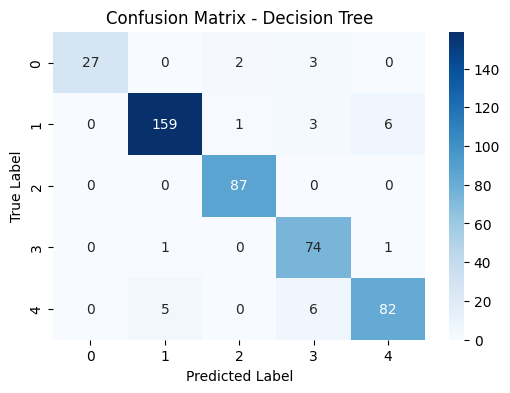


Evaluasi Model: Random Forest
Accuracy: 0.9694
F1-Score: 0.9694
Precision: 0.9704
Recall: 0.9694
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97        32
           1       0.98      0.95      0.97       169
           2       0.99      1.00      0.99        87
           3       0.92      1.00      0.96        76
           4       0.97      0.96      0.96        93

    accuracy                           0.97       457
   macro avg       0.97      0.97      0.97       457
weighted avg       0.97      0.97      0.97       457



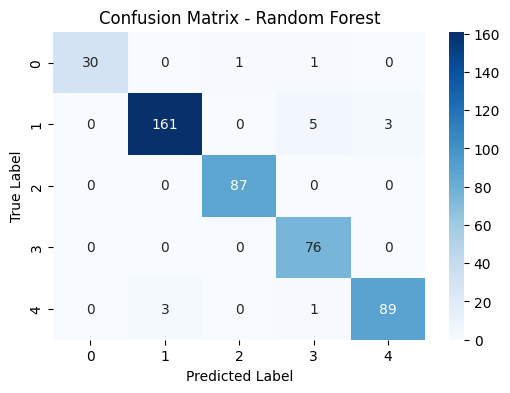

In [ ]:
# Evaluasi Model Sebelum Tuning

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    print(f"\nEvaluasi Model: {model_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=set(y_test), yticklabels=set(y_test))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

# Evaluasi Model Decision Tree
evaluate_model(dt_model, X_test, y_test, "Decision Tree")

# Evaluasi Model Random Forest
evaluate_model(rf_model, X_test, y_test, "Random Forest")

Berdasarkan hasil evaluasi model klasifikasi, Decision Tree dan Random Forest menunjukkan performa yang baik dalam melakukan prediksi, namun terdapat perbedaan dalam tingkat akurasi dan metrik evaluasi lainnya.

# 1. Decision Tree:

* Akurasi: 93.87%
* F1-Score: 93.86%
* Precision: 94.10%
* Recall: 93.87%

Decision Tree memiliki performa yang cukup baik dengan akurasi 93.87%, namun model ini cenderung rentan terhadap overfitting, terutama pada data dengan banyak cabang atau tanpa teknik pruning yang baik. Dari classification report, terlihat bahwa beberapa kelas memiliki nilai recall yang lebih rendah, misalnya kelas 0 (84%), yang menunjukkan bahwa model masih memiliki kesalahan dalam mengklasifikasikan beberapa data.

# 2. Random Forest:

* Akurasi: 96.94%
* F1-Score: 96.94%
* Precision: 97.04%
* Recall: 96.94%

Random Forest, yang merupakan pengembangan dari Decision Tree dengan metode ensemble learning, menunjukkan hasil yang lebih unggul dengan akurasi 96.94%. Model ini lebih stabil dan mampu mengurangi overfitting karena menggabungkan prediksi dari banyak pohon keputusan (trees). Dari classification report, terlihat bahwa setiap kelas memiliki precision dan recall yang lebih tinggi dibandingkan Decision Tree, yang berarti model lebih baik dalam menangani berbagai kategori data.

# Kesimpulan:

Dibandingkan dengan Decision Tree, Random Forest memiliki performa yang lebih baik dalam hal akurasi, precision, recall, dan F1-score. Hal ini dikarenakan mekanisme ensemble yang memperbaiki kelemahan individual Decision Tree dengan mengambil rata-rata prediksi dari banyak pohon keputusan. Oleh karena itu, jika tujuan utama adalah mendapatkan model dengan performa lebih tinggi dan lebih generalisasi, Random Forest adalah pilihan yang lebih baik dibandingkan Decision Tree.

## **c. Tuning Model Klasifikasi (Optional)**

Gunakan GridSearchCV, RandomizedSearchCV, atau metode lainnya untuk mencari kombinasi hyperparameter terbaik

In [ ]:
# Hyperparameter Tuning dengan GridSearchCV

# Hyperparameter Grid untuk Decision Tree
param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)
print("Best Params for Decision Tree:", grid_dt.best_params_)

# Hyperparameter Grid untuk Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)
print("Best Params for Random Forest:", grid_rf.best_params_)

Best Params for Decision Tree: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Params for Random Forest: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}


## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

Berikut adalah rekomendasi tahapannya.
1. Gunakan model dengan hyperparameter terbaik.
2. Hitung ulang metrik evaluasi untuk melihat apakah ada peningkatan performa.


Evaluasi Model: Decision Tree (Tuned)
Accuracy: 0.9606
F1-Score: 0.9604
Precision: 0.9621
Recall: 0.9606
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.84      0.92        32
           1       0.99      0.95      0.97       169
           2       0.97      1.00      0.98        87
           3       0.91      0.97      0.94        76
           4       0.94      0.98      0.96        93

    accuracy                           0.96       457
   macro avg       0.96      0.95      0.95       457
weighted avg       0.96      0.96      0.96       457



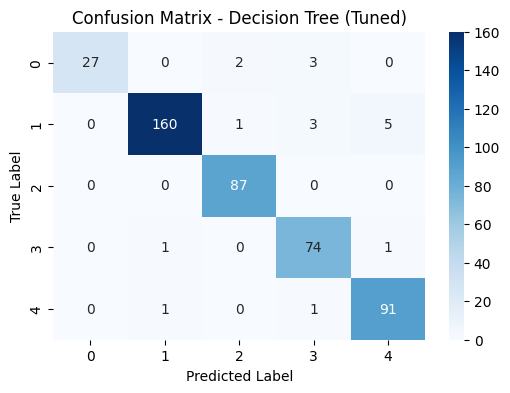


Evaluasi Model: Random Forest (Tuned)
Accuracy: 0.9628
F1-Score: 0.9630
Precision: 0.9644
Recall: 0.9628
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97        32
           1       0.99      0.94      0.97       169
           2       0.97      1.00      0.98        87
           3       0.90      0.97      0.94        76
           4       0.95      0.97      0.96        93

    accuracy                           0.96       457
   macro avg       0.96      0.96      0.96       457
weighted avg       0.96      0.96      0.96       457



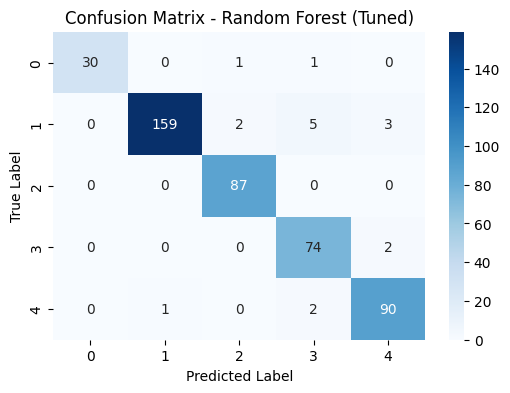

In [ ]:
# Evaluasi Model Setelah Tuning

# Model Decision Tree dengan Hyperparameter Terbaik
dt_best = grid_dt.best_estimator_
evaluate_model(dt_best, X_test, y_test, "Decision Tree (Tuned)")

# Model Random Forest dengan Hyperparameter Terbaik
rf_best = grid_rf.best_estimator_
evaluate_model(rf_best, X_test, y_test, "Random Forest (Tuned)")

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

# **Analisis Hasil Evaluasi Model Klasifikasi**
1. Perbandingan Hasil Evaluasi Sebelum dan Setelah Tuning

  Setelah dilakukan tuning, performa model Decision Tree mengalami peningkatan yang cukup signifikan. Akurasinya meningkat dari 93.87% menjadi 96.06%, dan F1-score naik dari 93.86% menjadi 96.04%. Sementara itu, Random Forest mengalami sedikit perubahan setelah tuning, dengan akurasi yang sedikit menurun dari 96.94% menjadi 96.28%, namun F1-score tetap stabil di sekitar 96.30%.

  Peningkatan performa pada Decision Tree menunjukkan bahwa tuning parameter seperti max_depth, min_samples_leaf, dan min_samples_split membantu model dalam melakukan generalisasi yang lebih baik. Sementara pada Random Forest, tuning tidak memberikan dampak yang terlalu besar, yang mengindikasikan bahwa model ini sudah cukup optimal sebelum tuning.

2. Identifikasi Kelemahan Model

  Salah satu kelemahan yang ditemukan adalah precision dan recall yang rendah pada kelas tertentu. Pada Decision Tree sebelum tuning, kelas 0 memiliki recall hanya 84%, yang berarti model masih kesulitan mengenali beberapa sampel dari kelas ini dengan baik. Setelah tuning, recall tetap belum meningkat secara signifikan, sehingga model masih berpotensi melewatkan beberapa sampel dari kelas tersebut.

  Pada Random Forest sebelum tuning, ditemukan bahwa kelas 3 memiliki precision 92% dan recall 100%, yang mengindikasikan bahwa model cenderung terlalu percaya diri dalam mengklasifikasikan sampel sebagai kelas 3. Setelah tuning, precision dan recall untuk kelas ini menjadi lebih seimbang, tetapi masih menunjukkan indikasi overfitting pada kelas tertentu.

  Dari segi kompleksitas, Decision Tree sebelum tuning kemungkinan mengalami overfitting, karena tidak ada batasan pada kedalaman pohon keputusan sehingga model terlalu menyesuaikan data latih. Setelah tuning dengan max_depth=10, model lebih stabil dan mampu melakukan prediksi dengan lebih baik. Sementara itu, Random Forest sejak awal sudah menunjukkan performa yang cukup baik, dan tuning parameter seperti n_estimators=200 serta min_samples_split=10 hanya memberikan perubahan kecil pada hasil akhir.

3. Rekomendasi Tindakan Lanjutan

Untuk menangani kelemahan model, beberapa langkah yang bisa dilakukan antara lain:

- Meningkatkan Keseimbangan Data

  Karena kelas tertentu memiliki recall rendah (misalnya kelas 0 pada Decision Tree), maka jumlah data untuk kelas tersebut perlu ditingkatkan. Teknik seperti SMOTE (Synthetic Minority Over-sampling Technique) bisa digunakan untuk menambah sampel pada kelas minoritas.
- Menghindari Overfitting

  Pada Decision Tree, bisa dilakukan pruning lebih lanjut agar model tidak terlalu menyesuaikan data latih. Pada Random Forest, mengurangi jumlah pohon (n_estimators) atau membatasi kedalaman pohon dapat membantu mengurangi kemungkinan overfitting.
- Eksperimen dengan Model Lain

  Karena hasil yang diperoleh masih belum memuaskan, bisa mencoba model lain seperti Gradient Boosting, XGBoost, atau LightGBM, yang sering memberikan hasil lebih optimal dibandingkan Decision Tree dan Random Forest dalam tugas klasifikasi.